## Week 8 — Multi-Fidelity GP (Matérn-5/2 ARD + LinTrunc) + MF-qNEI

This notebook fits a **Multi-Fidelity Gaussian Process (MFGP)** surrogate on all cumulative
Week 8 data and proposes the next warehouse configuration using **Cost-aware MF-qNEI**.

**Why MFGP for Week 8?**
- The MFGP with Matérn-5/2 ARD + `LinearTruncatedFidelityKernel` was the **Prequential Evaluation winner**
  for F4, achieving the best NLP of -1.35 across 45 tested configurations.
- Although all data is single-fidelity, the `LinearTruncatedFidelityKernel` provides beneficial
  regularisation via its structured prior on spatial-fidelity kernel interaction.
- **MF-qNEI** (q=4, 64 MC samples) jointly proposes 4 candidates; the best is selected for submission.

In [1]:
import copy
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskMultiFidelityGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood

# Suppress convergence warnings from L-BFGS during MLL fitting
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Hyperparameter Documentation

| # | Hyperparameter | Value | Justification |
|---|---------------|-------|---------------|
| 1 | Kernel ν (nu) | 2.5 | Matérn-5/2 — PE winner for F4 |
| 2 | `linear_truncated` | `True` | LinearTruncatedFidelityKernel; PE winner |
| 3 | ARD dimensions | 4 spatial + 1 fidelity | Each dimension gets its own lengthscale |
| 4 | Noise floor (`noise_lb`) | 1e-4 | Prevents noise collapsing to zero |
| 5 | Output standardisation | z-score | Manual `(y - mean) / std` |
| 6 | MLL restarts (`N_RESTARTS`) | 15 | Avoids local optima |
| 7 | Fidelity column | All 1.0 (column index 4) | Synthetic single-fidelity |
| 8 | `data_fidelities` | `[4]` | Column 4 = fidelity dimension |
| 9 | Acquisition | `qLogNoisyExpectedImprovement` | Log-space NEI |
| 10 | Batch size (`q`) | 4 | Joint optimisation; best selected |
| 11 | MC samples | 64 | `SobolQMCNormalSampler` |
| 12 | Acquisition restarts | 20 | Multi-start L-BFGS-B |
| 13 | Raw Sobol samples | 512 | Initialisation points |
| 14 | `fixed_features` | `{4: 1.0}` | Pin fidelity during acquisition |
| 15 | `prune_baseline` | `True` | Removes dominated baseline points |
| 16 | Spatial bounds | `[0, 0.999999]⁴` | Challenge format constraint |

In [2]:
# ── Constants ──
N_RESTARTS = 15
NOISE_LB = 1e-4
Q = 4
MC_SAMPLES = 64
ACQ_RESTARTS = 20
RAW_SAMPLES = 512
GRID_RES = 80
DIM = 4

### Step 1: Load Week 8 Data

In [3]:
# Load cumulative Week 8 data
X_raw = np.load('../../data/f4/updated_inputs - Week 8.npy')
y_raw = np.load('../../data/f4/updated_outputs - Week 8.npy')

n_samples = len(y_raw)
best_idx = y_raw.argmax()
best_val = y_raw[best_idx]

assert X_raw.shape == (38, 4), f"Expected (38, 4), got {X_raw.shape}"
assert y_raw.shape == (38,), f"Expected (38,), got {y_raw.shape}"

print(f"Week 8 Data Summary for F4")
print(f"{'='*40}")
print(f"Number of samples:  {n_samples}")
print(f"Input dimensions:   {X_raw.shape[1]}")
print(f"Input range:        [{X_raw.min():.6f}, {X_raw.max():.6f}]")
for dim in range(DIM):
    print(f"  Dim {dim+1}:            [{X_raw[:, dim].min():.6f}, {X_raw[:, dim].max():.6f}]")
print(f"Output range:       [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Output mean:        {y_raw.mean():.6f}")
print(f"Output std:         {y_raw.std():.6f}")
print(f"Best observed value: {best_val:.6f} (sample #{best_idx + 1})")

# Validate inputs in [0, 1]
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "Inputs out of [0, 1] range"
print(f"\n✓ All inputs are within [0.0, 1.0]")

Week 8 Data Summary for F4
Number of samples:  38
Input dimensions:   4
Input range:        [0.006250, 0.999483]
  Dim 1:            [0.037825, 0.985622]
  Dim 2:            [0.006250, 0.919592]
  Dim 3:            [0.012308, 0.939178]
  Dim 4:            [0.081517, 0.999483]
Output range:       [-32.625660, 0.532175]
Output mean:        -13.967009
Output std:         9.011157
Best observed value: 0.532175 (sample #33)

✓ All inputs are within [0.0, 1.0]


### Step 2: Train MFGP with 15 Random Restarts

Z-score standardise outputs, append fidelity column, then train with multi-restart MLL.

In [4]:
# Z-score standardise outputs
y_mean = float(y_raw.mean())
y_std_val = float(y_raw.std())
y_standardised = (y_raw - y_mean) / y_std_val

# Convert to torch tensors
X_train = torch.tensor(X_raw, dtype=torch.float64)
Y_train = torch.tensor(y_standardised, dtype=torch.float64).unsqueeze(-1)

# Append fidelity column (all 1.0) → 5D augmented input
fidelity_col = torch.ones(X_train.shape[0], 1, dtype=torch.float64)
X_mf = torch.cat([X_train, fidelity_col], dim=-1)
print(f"X_mf shape: {X_mf.shape}  (4 spatial + 1 fidelity)")
print(f"Y_train shape: {Y_train.shape}  (z-scored)")
print(f"y_mean={y_mean:.6f}, y_std={y_std_val:.6f}")

# Multi-restart MLL training
best_loss = float('inf')
best_model = None
best_seed = -1

print(f"\nTraining MFGP with {N_RESTARTS} random restarts...")
print(f"{'─'*55}")

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)
    try:
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))
        model = SingleTaskMultiFidelityGP(
            X_mf, Y_train,
            likelihood=likelihood,
            data_fidelities=[4],
            linear_truncated=True,
            nu=2.5,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        model.train()
        with torch.no_grad():
            output = model(X_mf)
            loss = -mll(output, Y_train.squeeze(-1)).item()

        status = f"neg_MLL = {loss:.4f}"
        if loss < best_loss:
            best_loss = loss
            best_model = copy.deepcopy(model)
            best_seed = seed
            status += " ★ new best"
    except Exception as e:
        status = f"FAILED ({type(e).__name__})"

    print(f"  Restart {seed+1:2d}/{N_RESTARTS}: {status}")

assert best_model is not None, "All restarts failed!"
best_model.eval()

# Extract fitted hyperparameters
fid_kernel = best_model.covar_module.base_kernel.kernels[0]
ls = fid_kernel.covar_module_unbiased.lengthscale.detach().squeeze()
outputscale = best_model.covar_module.outputscale.item()
noise = best_model.likelihood.noise.item()
power = fid_kernel.power.item()

print(f"\n{'='*55}")
print(f"Best Model (restart {best_seed+1}, neg_MLL = {best_loss:.4f})")
print(f"{'─'*55}")
for i in range(DIM):
    print(f"  ℓ{i+1} = {ls[i].item():.6f}")
print(f"  σ²_f (outputscale) = {outputscale:.6f}")
print(f"  σ²_n (noise)       = {noise:.6f}  {'✓ ≥ 1e-4' if noise >= NOISE_LB else '⚠️ below floor!'}")
print(f"  Fidelity power     = {power:.6f}")

X_mf shape: torch.Size([38, 5])  (4 spatial + 1 fidelity)
Y_train shape: torch.Size([38, 1])  (z-scored)
y_mean=-13.967009, y_std=9.011157

Training MFGP with 15 random restarts...
───────────────────────────────────────────────────────
  Restart  1/15: neg_MLL = 0.1907 ★ new best
  Restart  2/15: neg_MLL = 0.1907
  Restart  3/15: neg_MLL = 0.1907
  Restart  4/15: neg_MLL = 0.1907
  Restart  5/15: neg_MLL = 0.1907
  Restart  6/15: neg_MLL = 0.1907
  Restart  7/15: neg_MLL = 0.1907
  Restart  8/15: neg_MLL = 0.1907
  Restart  9/15: neg_MLL = 0.1907
  Restart 10/15: neg_MLL = 0.1907
  Restart 11/15: neg_MLL = 0.1907
  Restart 12/15: neg_MLL = 0.1907
  Restart 13/15: neg_MLL = 0.1907
  Restart 14/15: neg_MLL = 0.1907
  Restart 15/15: neg_MLL = 0.1907

Best Model (restart 1, neg_MLL = 0.1907)
───────────────────────────────────────────────────────
  ℓ1 = 0.803130
  ℓ2 = 0.800876
  ℓ3 = 0.787145
  ℓ4 = 0.758241
  σ²_f (outputscale) = 0.886157
  σ²_n (noise)       = 0.000100  ✓ ≥ 1e-4
  Fide

### Step 3: MF-qNEI Acquisition — Propose q=4 Candidates

Joint optimisation of 4 candidates with fidelity pinned at 1.0. Best candidate selected by highest de-standardised posterior mean.

In [5]:
# Sampler: 64 MC samples
sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

# Create acquisition function
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_mf,
    sampler=sampler,
    prune_baseline=True,
)

# Bounds: 4 spatial dims [0, 0.999999] + fidelity [1.0, 1.0]
BOUNDS = torch.tensor(
    [[0.0, 0.0, 0.0, 0.0, 1.0],
     [0.999999, 0.999999, 0.999999, 0.999999, 1.0]],
    dtype=torch.float64,
)

# Optimise acquisition (q=4, fidelity pinned at 1.0)
print(f"Optimising MF-qNEI (q={Q}, {MC_SAMPLES} MC samples, {ACQ_RESTARTS} restarts)...")
candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=Q,
    num_restarts=ACQ_RESTARTS,
    raw_samples=RAW_SAMPLES,
    fixed_features={4: 1.0},
)

# Extract spatial coordinates (drop fidelity column)
next_points = candidates[:, :DIM].detach().cpu().numpy()

print(f"\n{'='*60}")
print(f"MF-qNEI Results — {Q} Candidates")
print(f"{'─'*60}")
for i in range(Q):
    coords = ", ".join([f"{next_points[i, d]:.6f}" for d in range(DIM)])
    print(f"  Candidate {i+1}: [{coords}]")
print(f"{'─'*60}")
print(f"Joint acquisition value: {acq_value.item():.6f}")

# Select best candidate by posterior mean
with torch.no_grad():
    candidate_tensor = candidates.detach()
    posterior = best_model.posterior(candidate_tensor)
    posterior_means = posterior.mean.squeeze()
    posterior_means_orig = posterior_means * y_std_val + y_mean

best_candidate_idx = posterior_means_orig.argmax().item()
best_point = next_points[best_candidate_idx]

print(f"\nBest candidate: #{best_candidate_idx + 1} (posterior mean = {posterior_means_orig[best_candidate_idx].item():.6f})")
print(f"  Selected point: [{', '.join([f'{v:.6f}' for v in best_point])}]")

Optimising MF-qNEI (q=4, 64 MC samples, 20 restarts)...

MF-qNEI Results — 4 Candidates
────────────────────────────────────────────────────────────
  Candidate 1: [0.412682, 0.453115, 0.454916, 0.410018]
  Candidate 2: [0.399471, 0.422507, 0.393358, 0.398014]
  Candidate 3: [0.034348, 0.018101, 0.220005, 0.574271]
  Candidate 4: [0.411124, 0.434064, 0.426513, 0.405892]
────────────────────────────────────────────────────────────
Joint acquisition value: -4.108469

Best candidate: #4 (posterior mean = 0.518361)
  Selected point: [0.411124, 0.434064, 0.426513, 0.405892]


### Step 4: Surrogate Visualisation — 2D Slices

Project onto the two most important dimensions (shortest ARD lengthscales), fixing others at the proposed point.

ARD lengthscales: ['0.8031', '0.8009', '0.7871', '0.7582']
Top-2 dims (shortest ℓ): ['Dim 4', 'Dim 3']
Fixed dims: ['Dim 2', 'Dim 1'] at proposed point values


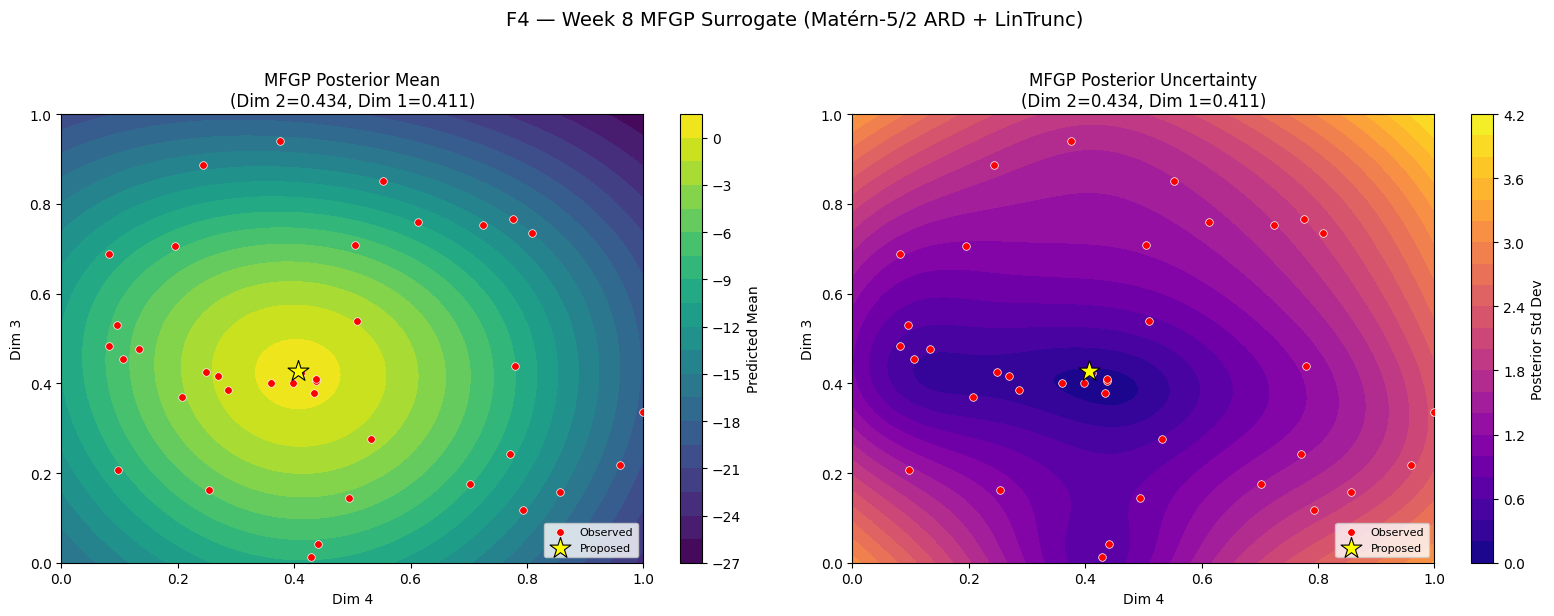

In [6]:
# Identify top-2 dims by shortest ARD lengthscales
lengthscales = ls.numpy()
dim_order = np.argsort(lengthscales)
top2 = dim_order[:2].tolist()
fix2 = dim_order[2:].tolist()
dim_names = ['Dim 1', 'Dim 2', 'Dim 3', 'Dim 4']

print(f"ARD lengthscales: {['%.4f' % l for l in lengthscales]}")
print(f"Top-2 dims (shortest ℓ): {[dim_names[d] for d in top2]}")
print(f"Fixed dims: {[dim_names[d] for d in fix2]} at proposed point values")

# Build grid over top-2 dims
g1 = np.linspace(0, 1, GRID_RES)
g2 = np.linspace(0, 1, GRID_RES)
mesh1, mesh2 = np.meshgrid(g1, g2)

grid_points = np.zeros((GRID_RES * GRID_RES, DIM))
grid_points[:, top2[0]] = mesh1.ravel()
grid_points[:, top2[1]] = mesh2.ravel()
for fd in fix2:
    grid_points[:, fd] = best_point[fd]

# Append fidelity column for MFGP
fid_col = np.ones((GRID_RES * GRID_RES, 1))
grid_5d = np.hstack([grid_points, fid_col])
grid_tensor = torch.tensor(grid_5d, dtype=torch.float64)

with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    mean_std = posterior.mean.squeeze().numpy()
    std_std = posterior.variance.squeeze().sqrt().numpy()

mean_orig = mean_std * y_std_val + y_mean
std_orig = std_std * y_std_val

mean_grid = mean_orig.reshape(GRID_RES, GRID_RES)
std_grid = std_orig.reshape(GRID_RES, GRID_RES)

# 2-panel: mean + std
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cf1 = ax1.contourf(mesh1, mesh2, mean_grid, levels=20, cmap='viridis')
plt.colorbar(cf1, ax=ax1, label='Predicted Mean')
ax1.scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='red', s=30,
            edgecolors='white', linewidths=0.5, zorder=5, label='Observed')
ax1.scatter(best_point[top2[0]], best_point[top2[1]], marker='*', c='yellow',
            s=250, edgecolors='black', linewidths=0.8, zorder=6, label='Proposed')
ax1.set_xlabel(dim_names[top2[0]])
ax1.set_ylabel(dim_names[top2[1]])
ax1.set_title(f'MFGP Posterior Mean\n({dim_names[fix2[0]]}={best_point[fix2[0]]:.3f}, '
              f'{dim_names[fix2[1]]}={best_point[fix2[1]]:.3f})')
ax1.legend(loc='lower right', fontsize=8)

cf2 = ax2.contourf(mesh1, mesh2, std_grid, levels=20, cmap='plasma')
plt.colorbar(cf2, ax=ax2, label='Posterior Std Dev')
ax2.scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='red', s=30,
            edgecolors='white', linewidths=0.5, zorder=5, label='Observed')
ax2.scatter(best_point[top2[0]], best_point[top2[1]], marker='*', c='yellow',
            s=250, edgecolors='black', linewidths=0.8, zorder=6, label='Proposed')
ax2.set_xlabel(dim_names[top2[0]])
ax2.set_ylabel(dim_names[top2[1]])
ax2.set_title(f'MFGP Posterior Uncertainty\n({dim_names[fix2[0]]}={best_point[fix2[0]]:.3f}, '
              f'{dim_names[fix2[1]]}={best_point[fix2[1]]:.3f})')
ax2.legend(loc='lower right', fontsize=8)

plt.suptitle('F4 — Week 8 MFGP Surrogate (Matérn-5/2 ARD + LinTrunc)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step 5: Convergence Plot

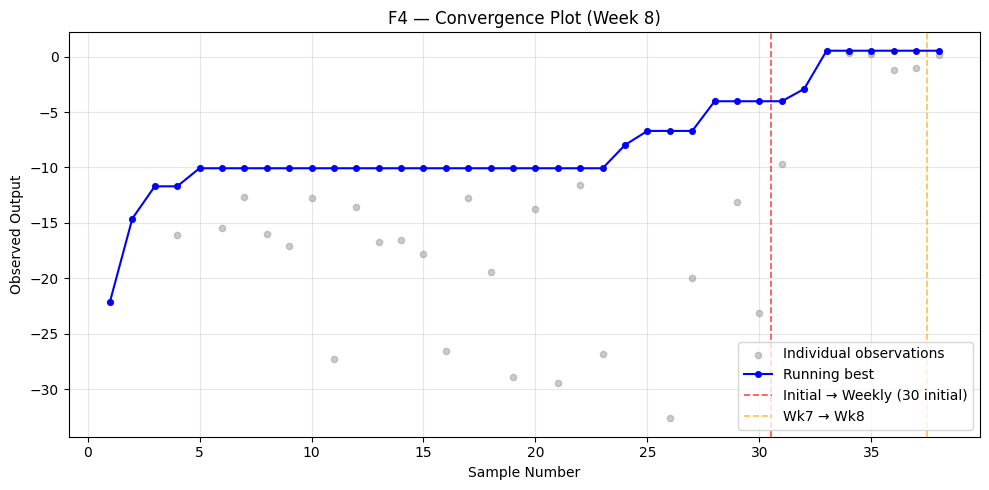

Best after initial 30 samples: -4.025542
Best after Week 8 (38 samples): 0.532175
Improvement from weekly submissions: 4.557718


In [7]:
# Convergence plot
running_best = np.maximum.accumulate(y_raw)
sample_numbers = np.arange(1, len(y_raw) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample_numbers, y_raw, c='gray', alpha=0.4, s=20,
           label='Individual observations', zorder=3)
ax.plot(sample_numbers, running_best, 'b-o', markersize=4, linewidth=1.5,
        label='Running best', zorder=4)
ax.axvline(x=30.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Initial → Weekly (30 initial)')
ax.axvline(x=37.5, color='orange', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Wk7 → Wk8')

ax.set_xlabel('Sample Number')
ax.set_ylabel('Observed Output')
ax.set_title('F4 — Convergence Plot (Week 8)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best after initial 30 samples: {running_best[29]:.6f}")
print(f"Best after Week 8 ({n_samples} samples): {running_best[-1]:.6f}")
improvement = running_best[-1] - running_best[29]
print(f"Improvement from weekly submissions: {improvement:.6f}")

### Step 6: Format Submission

Select the best-of-4 candidate, clamp to [0, 0.999999], and format as 4-component dash-separated string.

In [8]:
# Clamp and format
clamped = np.clip(best_point, 0.0, 0.999999)
submission = "-".join([f"{x:.6f}" for x in clamped])

# Validate
parts = submission.split("-")
valid = (len(parts) == DIM and
         all(p[0] == '0' for p in parts) and
         all(0.0 <= float(p) <= 1.0 for p in parts))

# Duplicate check
distances = np.linalg.norm(X_raw - clamped, axis=1)
min_dist = distances.min()
is_duplicate = min_dist < 1e-6

print(f"F4 Week 8 — Submission Summary")
print(f"{'='*55}")
print(f"Surrogate:    MFGP (Matérn-5/2 ARD + LinTrunc)")
print(f"Acquisition:  MF-qNEI (q={Q}, {MC_SAMPLES} MC samples)")
print(f"{'─'*55}")
print(f"Fitted hyperparameters:")
for i in range(DIM):
    print(f"  ℓ{i+1} = {ls[i].item():.6f}")
print(f"  σ²_f = {outputscale:.6f}")
print(f"  σ²_n = {noise:.6f}")
print(f"{'─'*55}")
print(f"Proposed point: [{', '.join([f'{v:.6f}' for v in best_point])}]")
if is_duplicate:
    print(f"⚠️  Near-duplicate at distance {min_dist:.8f}")
else:
    print(f"✓ No duplicate (min dist: {min_dist:.6f})")
print(f"{'─'*55}")
print(f"\n>>> SUBMISSION QUERY:")
print(submission)
print(f"\nFormat valid: {'✓ YES' if valid else '✗ NO'}")

F4 Week 8 — Submission Summary
Surrogate:    MFGP (Matérn-5/2 ARD + LinTrunc)
Acquisition:  MF-qNEI (q=4, 64 MC samples)
───────────────────────────────────────────────────────
Fitted hyperparameters:
  ℓ1 = 0.803130
  ℓ2 = 0.800876
  ℓ3 = 0.787145
  ℓ4 = 0.758241
  σ²_f = 0.886157
  σ²_n = 0.000100
───────────────────────────────────────────────────────
Proposed point: [0.411124, 0.434064, 0.426513, 0.405892]
✓ No duplicate (min dist: 0.034620)
───────────────────────────────────────────────────────

>>> SUBMISSION QUERY:
0.411124-0.434064-0.426513-0.405892

Format valid: ✓ YES
